<a href="https://colab.research.google.com/github/Divyanshiii-23/BRAINS/blob/main/Portfolio_Analysis_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas numpy matplotlib scipy statsmodels --quiet

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

Imagine you have $10,000 and want to invest in tech stocks (Facebook/Meta, Apple, Amazon, Netflix, Google). But before you invest, you want to know: "What's the worst that could happen to my money?"

Historical Method - "Looking at the Past"

Like checking weather patterns from the last 2 years to predict tomorrow's weather
Takes actual stock price movements from the past 800 days
Says: "Based on history, there's a 5% chance you could lose more than $X"

In [ ]:
def getData(stocks, start, end):
    stockData = yf.download(stocks, start=start, end=end)['Close']
    returns = stockData.pct_change()
    meanReturns = returns.mean()
    covMatrix = returns.cov()
    return returns, meanReturns, covMatrix

# Portfolio performance
def portfolioPerformance(weights, meanReturns, covMatrix, Time):
    returns = np.sum(meanReturns*weights)*Time
    std = np.sqrt(np.dot(weights.T, np.dot(covMatrix, weights))) * np.sqrt(Time)
    return returns, std

# Define FAANG stock list
stockList = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOGL']
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*5)

# Run everything
returns, meanReturns, covMatrix = getData(stockList, start=startDate, end=endDate)
returns = returns.dropna()

weights = np.random.random(len(stockList))
weights /= np.sum(weights)

returns['portfolio'] = returns.dot(weights)

/tmp/ipython-input-30-3007742258.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockData = yf.download(stocks, start=start, end=end)['Close']
[*********************100%***********************]  5 of 5 completed


## Risk Metrics: VaR vs CVaR

### 🔸 **VaR (Value at Risk)**  
> "In the worst 5% of cases, I won't lose more than $X."

- Think of VaR as:  
  **"The minimum loss in your worst-case scenario"**  
- It answers:  
  *"What’s the most I could lose with 95% confidence?"*

---

### 🔸 **CVaR (Conditional Value at Risk)**  
> "If I'm in that unlucky 5%, on average I'll lose $X."

- Think of CVaR as:  
  **"The average loss when things go really bad"**  
- It tells you:  
  *"If my losses exceed VaR, how bad do they get on average?"*

---

### Intuition Summary:

| Metric | Interpretation |
|--------|----------------|
| **VaR**  | Minimum loss in the worst X% of outcomes |
| **CVaR** | Average loss within that worst X%       |


Normal Distribution - "Assuming Perfect Bell Curve"

Assumes stock returns follow a perfect mathematical curve (like height distribution in a population)
Very clean and mathematical, but real markets are messier than this
Fastest to calculate but often underestimates risk

In [ ]:
def historicalVaR(returns, alpha=5):

    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)

    elif isinstance(returns, pd.DataFrame):
        return returns.aggregate(historicalVaR, alpha=alpha)

    else:
        raise TypeError("Expected returns to be dataframe or series")

def historicalCVaR(returns, alpha=5):
    if isinstance(returns, pd.Series):
        belowVaR = returns <= historicalVaR(returns, alpha=alpha)
        return returns[belowVaR].mean()

    elif isinstance(returns, pd.DataFrame):
        return returns.aggregate(historicalCVaR, alpha=alpha)

    else:
        raise TypeError("Expected returns to be dataframe or series")

Time = 100

hVaR = -historicalVaR(returns['portfolio'], alpha=5)*np.sqrt(Time)
hCVaR = -historicalCVaR(returns['portfolio'], alpha=5)*np.sqrt(Time)
pRet, pStd = portfolioPerformance(weights, meanReturns, covMatrix, Time)

InitialInvestment = 10000
print('Expected Portfolio Return:      ', round(InitialInvestment*pRet,2))
print('Value at Risk 95th CI    :      ', round(InitialInvestment*hVaR,2))
print('Conditional VaR 95th CI  :      ', round(InitialInvestment*hCVaR,2))

Expected Portfolio Return:       963.14
Value at Risk 95th CI    :       3030.37
Conditional VaR 95th CI  :       4545.98


T-Distribution - "Accounting for Fat Tails"

Like the normal distribution but admits "crazy things happen more often than expected"
Better at capturing those "Black Swan" events (market crashes, sudden spikes)
More realistic than normal distribution

In [ ]:
def var_parametric(portofolioReturns, portfolioStd, distribution='normal', alpha=5, dof=6):
    if distribution == 'normal':
        VaR = norm.ppf(1-alpha/100)*portfolioStd - portofolioReturns
    elif distribution == 't-distribution':
        nu = dof
        VaR = np.sqrt((nu-2)/nu) * t.ppf(1-alpha/100, nu) * portfolioStd - portofolioReturns
    else:
        raise TypeError("Expected distribution type 'normal'/'t-distribution'")
    return VaR

def cvar_parametric(portofolioReturns, portfolioStd, distribution='normal', alpha=5, dof=6):
    if distribution == 'normal':
        CVaR = (alpha/100)**-1 * norm.pdf(norm.ppf(alpha/100))*portfolioStd - portofolioReturns
    elif distribution == 't-distribution':
        nu = dof
        xanu = t.ppf(alpha/100, nu)
        CVaR = -1/(alpha/100) * (1-nu)**(-1) * (nu-2+xanu**2) * t.pdf(xanu, nu) * portfolioStd - portofolioReturns
    else:
        raise TypeError("Expected distribution type 'normal'/'t-distribution'")
    return CVaR

normVaR = var_parametric(pRet, pStd)
normCVaR = cvar_parametric(pRet, pStd)

tVaR = var_parametric(pRet, pStd, distribution='t-distribution')
tCVaR = cvar_parametric(pRet, pStd, distribution='t-distribution')

print("Normal VaR 95th CI       :      ", round(InitialInvestment*normVaR,2))
print("Normal CVaR 95th CI      :      ", round(InitialInvestment*normCVaR,2))
print("t-dist VaR 95th CI       :      ", round(InitialInvestment*tVaR,2))
print("t-dist CVaR 95th CI      :      ", round(InitialInvestment*tCVaR,2))

Normal VaR 95th CI       :       2260.74
Normal CVaR 95th CI      :       3079.74
t-dist VaR 95th CI       :       2146.57
t-dist CVaR 95th CI      :       3262.9


Monte Carlo Simulation - "Running 400 Parallel Universes"

This is the coolest part!
Creates 400 different "what-if" scenarios of how your portfolio might perform over 100 days
Each simulation is like rolling dice 100 times for each stock, then seeing your total result
Gives you a range of possible outcomes

In [ ]:
# Monte Carlo Method
# 400 simulations = 400 different "what-if" stories about our portfolio
mc_sims = 400 # number of simulations
T = 100 #timeframe in days

meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

initialPortfolio = 10000

for m in range(0, mc_sims):
    # MC loops
    # Let's generate random market movements (sampling)
    Z = np.random.normal(size=(T, len(weights)))
    # Let's take into account the realistic behavior of stock moving together or not in the simulation also
    L = np.linalg.cholesky(covMatrix)
    #Check the image below for cholesky decomposition
    dailyReturns = meanM + np.inner(L, Z)
    #Calculate Portfolio Value each day
    portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio

cholesky decomposition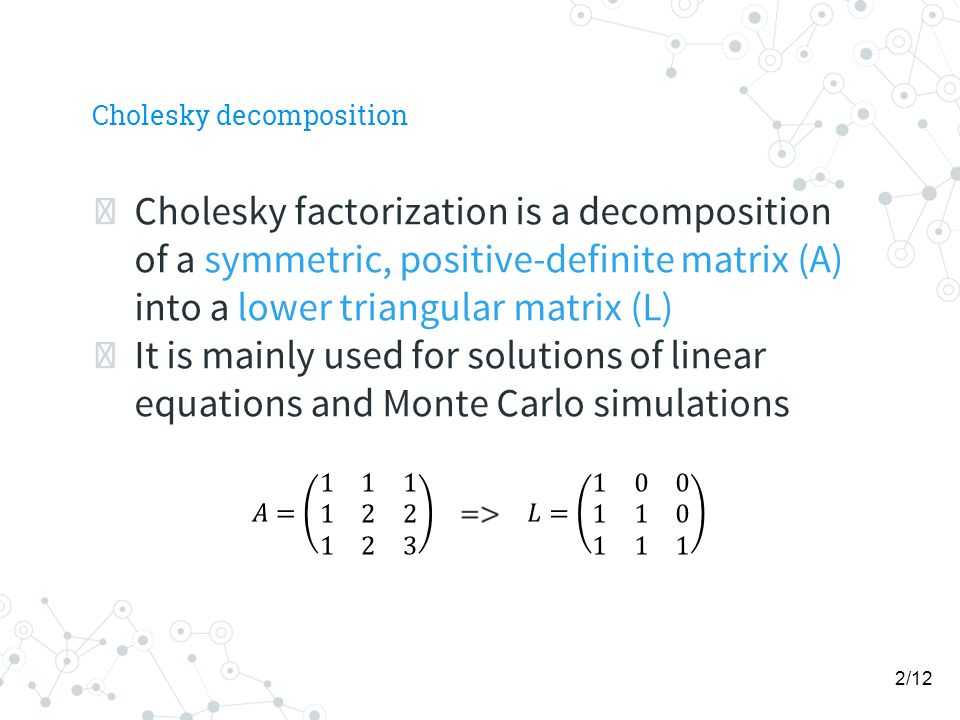

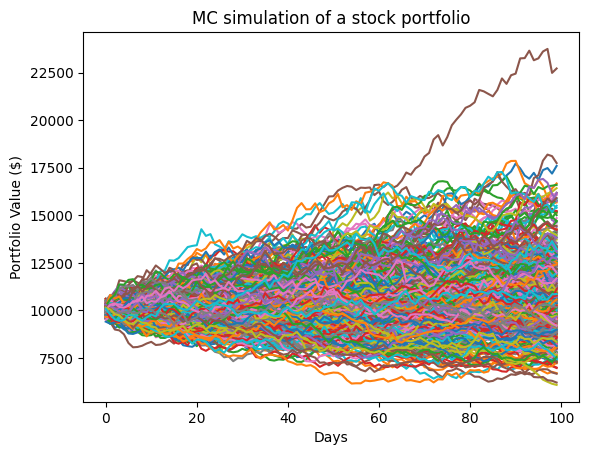

In [ ]:
plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.title('MC simulation of a stock portfolio')
plt.show()

In [ ]:
def mcVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: percentile on return distribution to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        raise TypeError("Expected a pandas data series.")

def mcCVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: CVaR or Expected Shortfall to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        belowVaR = returns <= mcVaR(returns, alpha=alpha)
        return returns[belowVaR].mean()
    else:
        raise TypeError("Expected a pandas data series.")

In [ ]:
portResults = pd.Series(portfolio_sims[-1,:])

VaR = initialPortfolio - mcVaR(portResults, alpha=5)
CVaR = initialPortfolio - mcCVaR(portResults, alpha=5)

print('VaR ${}'.format(round(VaR,2)))
print('CVaR ${}'.format(round(CVaR,2)))

VaR $2333.36
CVaR $2836.51


In [ ]:
print("\nVaR:")

print(' historical VaR 95th CI   :      ', round(InitialInvestment*hVaR,2))
print(" Normal VaR 95th CI       :      ", round(InitialInvestment*normVaR,2))
print(" t-dist VaR 95th CI       :      ", round(InitialInvestment*tVaR,2))
print(" MC VaR  95th CI          :      ", round(VaR,2))


print("\nCVaR:")

print(' historical CVaR 95th CI  :      ', round(InitialInvestment*hCVaR,2))
print(" Normal CVaR 95th CI      :      ", round(InitialInvestment*normCVaR,2))
print(" t-dist CVaR 95th CI      :      ", round(InitialInvestment*tCVaR,2))
print(" MC CVaR 95th CI          :      ", round(CVaR,2))


VaR:
 historical VaR 95th CI   :       3030.37
 Normal VaR 95th CI       :       2260.74
 t-dist VaR 95th CI       :       2146.57
 MC VaR  95th CI          :       2333.36

CVaR:
 historical CVaR 95th CI  :       4545.98
 Normal CVaR 95th CI      :       3079.74
 t-dist CVaR 95th CI      :       3262.9
 MC CVaR 95th CI          :       2836.51


## Why This Risk Analysis Matters

### **Professional-Grade Risk Management**
Banks, hedge funds, and asset managers use these exact methods to manage **billions of dollars** — you're applying industry-grade techniques.

---

### **Multiple Perspectives**
You're not relying on just one model. You're combining **four different approaches** (Historical, Parametric, Monte Carlo, etc.) to get a **well-rounded view of risk**.

---

### **Real-World Application**
This isn’t just theory — you're using **actual stock market data** to make **realistic investment decisions**, not toy examples.

---

### **Stress Testing with Monte Carlo**
Monte Carlo simulation runs **hundreds of stress-test scenarios** on your portfolio, helping you see how it might behave in extreme conditions.

---

### **Quantified Uncertainty**
You're not vaguely saying “investing is risky” — you're assigning **actual dollar values** to risk using **VaR** and **CVaR**.

#### Example:
There’s a 5% chance I’ll lose more than $1,200 (VaR).
If that happens, my average loss will be around $1,800(CVar).